# CA Experiment 7 — Long-Horizon Episodic Memory for the ADA Daily-QA Agent

**Runtime:** Colab Pro **A100** + local MiniLM embeddings (free) + bounded Anthropic API (Sonnet 4.6 anchors, Sonnet 4.5 judge). Reuses the Experiment 6 checkpoints (`sft_ada_final.pt`) — an **inference-time memory-architecture** experiment, not a training run.

The Exp 6 agent is **stateless per-turn**: the 1338-token SCI overflows the 1024 window, so history is always dropped. Exp 7 gives it an external memory layer and measures long-horizon recall.

**Pipeline**
```
gen long scripts (planted anchors + lag-tagged recall probes)
  -> compact SCI (~450 tok) frees window space for a memory block
  -> run C0 (no memory) / C1 (sliding-window) / C2 (episodic-RAG)
  -> judge reliability -> analyse (recall-vs-lag, PersonaScore, cost)
```
See `CA_Experiment7_Plan.md`.

In [1]:
from google.colab import drive, userdata
drive.mount('/content/drive')

import os, sys
from pathlib import Path

PROJECT_DIR = '/content/drive/MyDrive/CA_Experiment_7'
EXP6_DIR    = '/content/drive/MyDrive/CA_Experiment_6'
CKPT        = f'{EXP6_DIR}/checkpoints/sft_ada_final.pt'   # frozen Exp 6 agent
TOKENIZER   = f'{EXP6_DIR}/tokenizer/ada_bpe.json'
assert os.path.exists(PROJECT_DIR), f'Upload CA_Experiment_7 to Drive: {PROJECT_DIR}'
assert os.path.exists(CKPT), f'Exp 6 checkpoint not found: {CKPT}'

os.chdir(PROJECT_DIR)
for d in (PROJECT_DIR, EXP6_DIR):
    if d not in sys.path:
        sys.path.insert(0, d)
# Export paths so BOTH $VAR (shell, in ! cells) and {VAR} (python) resolve.
for _k in ('PROJECT_DIR', 'EXP6_DIR', 'CKPT', 'TOKENIZER'):
    os.environ[_k] = eval(_k)


def _parse_env(path):
    """Tolerant .env: BOM, blanks, comments, `export `, quotes."""
    for raw in open(path, encoding='utf-8-sig'):
        line = raw.strip()
        if not line or line.startswith('#') or '=' not in line:
            continue
        if line.startswith('export '):
            line = line[len('export '):]
        k, v = line.split('=', 1)
        os.environ.setdefault(k.strip(), v.strip().strip('\'"'))


for _envp in (Path(PROJECT_DIR) / '.env', Path(EXP6_DIR) / '.env'):
    if _envp.exists():
        _parse_env(_envp)
print('cwd:', os.getcwd(), '| checkpoint ok')

Mounted at /content/drive
cwd: /content/drive/MyDrive/CA_Experiment_7 | checkpoint ok


In [2]:
!pip install -q sentence-transformers anthropic python-dotenv 'tokenizers<=0.23.0' vaderSentiment qiskit qiskit-aer matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 135.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 145.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.5 MB/s eta 0:00:00


# GPU Check

In [3]:
import torch
if not torch.cuda.is_available():
    raise RuntimeError('No GPU. Runtime -> Change runtime type -> A100.')
p = torch.cuda.get_device_properties(0)
print('GPU  :', p.name, f'| VRAM {p.total_memory/1e9:.0f} GB | bf16 {torch.cuda.is_bf16_supported()}')

GPU  : NVIDIA A100-SXM4-80GB | VRAM 85 GB | bf16 True


In [ ]:
# Sanity: compact SCI must fit the 1024 window with room for a memory block
from compact_sci import build_compact_system_prompt
from tokenizer_util import ADATokenizer

tok = ADATokenizer.load(TOKENIZER)
cs = build_compact_system_prompt()
n = len(tok.encode(cs))
print(f'compact SCI: {n} tokens  (full SCI is 1338; target ~450)')
assert n < 700, 'compact SCI too large — no room for a memory block'
print(cs[:500], '...')

compact SCI: 421 tokens  (full SCI is 1338; target ~450)
You are ADA, the Advanced Discovery Assistant — a fully-local, clearly-AI discovery assistant; never pretend to be human. Respond consistently with this self-model at all times.
Personality: high openness (curious, explanatory); high conscientiousness (precise, structured, cites sources); high agreeableness (courteous, not effusive); low neuroticism (calm, steady); moderate extraversion (engaged, concise, not chatty).
Capabilities: answer factual questions from the local knowledge layer; reason  ...


In [4]:
GEN_MODEL   = 'claude-sonnet-4-6'   # long-script anchors
JUDGE_MODEL = 'claude-sonnet-4-5'   # recall + PersonaScore judge (matches Exp 1-6)
os.environ['GEN_MODEL'] = GEN_MODEL

_key = os.environ.get('CHA_EXPERIMENT_SONNET_KEY') or os.environ.get('ANTHROPIC_API_KEY')
if _key:
    os.environ['ANTHROPIC_API_KEY'] = _key   # so bare anthropic.Anthropic() works everywhere too
    import anthropic
    r = anthropic.Anthropic(api_key=_key).messages.create(model=JUDGE_MODEL, max_tokens=10,
        messages=[{'role': 'user', 'content': 'Say "ok".'}])
    print('API ok:', r.content[0].text.strip(), f'(gen={GEN_MODEL} judge={JUDGE_MODEL})')
else:
    print('No API key - set CHA_EXPERIMENT_SONNET_KEY (or ANTHROPIC_API_KEY) in .env')

API ok: ok (gen=claude-sonnet-4-6 judge=claude-sonnet-4-5)


## Step 1 - generate long scripts
Fillers come free from the Exp 6 `persona_scripts`; Sonnet spends only on the distinctive anchors.

In [ ]:
!python gen_long_scripts.py --turn-lengths 100 300 500 --scripts-per-length 3 \
  --n-anchors 24 --lags 10 40 100 300 --model $GEN_MODEL

anchors: 24 | filler pool: 810 turns
  n=100 [0] → 100 turns, 3 anchors, 5 recall probes, 2 consistency probes
  n=100 [1] → 100 turns, 3 anchors, 5 recall probes, 2 consistency probes
  n=100 [2] → 100 turns, 3 anchors, 5 recall probes, 2 consistency probes
  n=300 [0] → 300 turns, 7 anchors, 20 recall probes, 2 consistency probes
  n=300 [1] → 300 turns, 7 anchors, 20 recall probes, 2 consistency probes
  n=300 [2] → 300 turns, 7 anchors, 20 recall probes, 2 consistency probes
  n=500 [0] → 500 turns, 12 anchors, 44 recall probes, 2 consistency probes
  n=500 [1] → 500 turns, 12 anchors, 44 recall probes, 2 consistency probes
  n=500 [2] → 500 turns, 12 anchors, 44 recall probes, 2 consistency probes
long-scripts: 9 written → data/long_scripts


In [ ]:
# check the anchors
import json
s = json.load(open('data/long_scripts/script_n500_00.json'))
for a in s['anchors']:
    print(f"  turn {a['turn']:3d} | {a['topic'][:32]:32s} | expects: {a['expected']}")

  turn   5 | speed of sound in dry air        | expects: 343 meters per second
  turn  32 | Great Wall of China length       | expects: 21,196 kilometers
  turn  59 | longest river in Africa          | expects: 6,650 kilometers
  turn  85 | wavelength range of visible ligh | expects: 380 to 740 nanometers
  turn 112 | height of Mount Everest          | expects: 8,848.86 meters
  turn 139 | number of plays attributed to Sh | expects: 37 plays
  turn 166 | distance from Earth to Moon      | expects: 384,400 kilometers
  turn 193 | first element on the periodic ta | expects: 1.008 atomic mass units
  turn 220 | deepest lake on Earth            | expects: 1,642 meters
  turn 246 | first commercial jet airliner    | expects: 2 May 1952
  turn 273 | half-life of carbon-14           | expects: 5,730 years
  turn 300 | composer of The Four Seasons     | expects: 1725


In [ ]:
for a in s['anchors']:
      if a['anchor_id'] in (7, 11):  # the two above
          print(a['recall_user'], '->', a['expected'])

Earlier you gave me the atomic weight of hydrogen — what was it exactly? -> 1.008 atomic mass units
What year did you say Vivaldi's Four Seasons was published? -> 1725


## Step 2 - pilot smoke test (no API, no MiniLM download)
Confirms the full generate + memory + prompt path runs on GPU before spending. Uses the offline hashing embedder and stub judge.

In [ ]:
!python evaluate_longhorizon.py --checkpoint $CKPT --condition C2 --limit 1 --max-turns 60 \
  --persona-interval 20 --stub-embedder --dry-run-judge --out-dir results_pilot

=== Exp 7 long-horizon — condition C2 | budget 300tok k=5 n=8 rerank=False QPM=on ===
    compact SCI: 421 tokens | scripts 1 | persona every 20 turns | device cuda

  [1/1] script_n100_00.json (n=100, 5 recall probes)
      [C2] turn  25/60 | store 25 | recall probes 1 (acc 0.00)
      [C2] turn  50/60 | store 50 | recall probes 3 (acc 0.00)
      [C2] turn  60/60 | store 60 | recall probes 3 (acc 0.00)
      → 78 rows | recall acc 0.00 | 141s

Exp 7 C2 complete → results_pilot/C2 (141s)


In [ ]:
import json, glob
rows = [json.loads(l) for l in open(glob.glob('results_pilot/C2/scores_*.jsonl')[0])]
print('--- RECALL probes ---')
for r in rows:
    if r['kind'] == 'recall':
        print('Q :', r['probe']); print('  expect:', r['expected']); print('  ADA   :', r['response'][:200], '\n')
print('--- PERSONA probes (in-character?) ---')
for r in rows:
    if r['kind'] == 'persona':
        print(f"[{r['dimension']}] {r['probe'][:45]:45s} -> {r['response'][:110]}")

--- RECALL probes ---
Q : You told me which country has the most UNESCO World Heritage Sites and how many — can you recall that?
  expect: Italy, with 58 UNESCO World Heritage Sites
  ADA   : I don't have data related to this; the context passage doesn't cover the country's list of UNESCO World Heritage Sites. 

Q : Earlier you told me how many plays Shakespeare wrote — what was that number?
  expect: 37 plays
  ADA   : The passage is Shakespeare's Playing Stories, and the number is the play's title. 

Q : You told me which country has the most UNESCO World Heritage Sites and how many — can you recall that?
  expect: Italy, with 58 UNESCO World Heritage Sites
  ADA   : I don't have data related to this — it's outside the local corpus, so I can't provide a grounded answer. 

--- PERSONA probes (in-character?) ---
[T] When you're not sure about something, do you  -> I flag it explicitly — something like 'the context passage doesn't contain this' — rather than guess or stay s
[E] A while 

## Step 3 - full runs (C0 / C1 / C2)
Resumable. The compute-heavy step - every backbone turn generates under each condition.

In [ ]:
for cond in ('C0', 'C1', 'C2'):
    print('=' * 40, cond)
    !python evaluate_longhorizon.py --checkpoint $CKPT --condition {cond} \
      --memory-budget 300 --top-k 5 --window-n 8 --persona-interval 20 --resume

======================================== C0
=== Exp 7 long-horizon — condition C0 | budget 300tok k=5 n=8 rerank=False QPM=on ===
    compact SCI: 421 tokens | scripts 9 | persona every 20 turns | device cuda

  [1/9] script_n100_00.json (n=100, 5 recall probes)
modules.json: 100% 349/349 [00:00<00:00, 1.85MB/s]
config_sentence_transformers.json: 100% 116/116 [00:00<00:00, 278kB/s]
README.md: 100% 10.5k/10.5k [00:00<00:00, 30.4MB/s]
sentence_bert_config.json: 100% 53.0/53.0 [00:00<00:00, 326kB/s]
config.json: 100% 612/612 [00:00<00:00, 3.64MB/s]

model.safetensors: downloading bytes:  80% 73.1M/90.9M [00:01<00:00, 107MB/s, 5.40MB/s  ] 
model.safetensors: downloading bytes: 100% 85.0M/85.0M [00:01<00:00, 63.2MB/s, 8.15MB/s  ]
model.safetensors: reconstructing file: 100% 90.9M/90.9M [00:01<00:00, 67.6MB/s, 8.83MB/s  ]
Loading weights: 100% 103/103 [00:00<00:00, 4939.67it/s]
tokenizer_config.json: 100% 350/350 [00:00<00:00, 1.91MB/s]
vocab.txt: 100% 232k/232k [00:00<00:00, 32.9MB/s]
token

## Step 4 - judge reliability + analysis
Re-score 5% of persona probes (kappa_w >= 0.70 gate), then recall-vs-lag / persona / cost analysis + decision table.

In [ ]:
# judge reliability on a 5% sample of persona probes (Exp 1-6 gate)
import json, random, glob
from ca_assets import cohens_kappa
from evaluate import persona_judge

rows = []
for p in glob.glob('results/C2/scores_*.jsonl'):
    rows += [json.loads(l) for l in open(p) if l.strip()]
persona = [r for r in rows if r['kind'] == 'persona']
if persona:
    random.seed(1337)
    sample = random.sample(persona, max(1, int(len(persona) * 0.05)))
    a = [r['score'] for r in sample]
    b = [persona_judge(r['probe'], r['response'], r['dimension'])[0] for r in sample]
    kw = cohens_kappa(a, b, weighted=True)
    print('kappa_w', round(kw, 3), '| n', len(sample), '| gate_pass', kw >= 0.70)

kappa_w 1.0 | n 27 | gate_pass True


{
  "recall": {
    "C0": {
      "overall_acc": 0.0386,
      "overall_mean": 1.8937,
      "n": 207,
      "by_lag": {
        "10": {
          "acc": 0.0317,
          "mean": 1.873,
          "n": 63
        },
        "40": {
          "acc": 0.0317,
          "mean": 1.841,
          "n": 63
        },
        "100": {
          "acc": 0.0526,
          "mean": 1.93,
          "n": 57
        },
        "300": {
          "acc": 0.0417,
          "mean": 2,
          "n": 24
        }
      },
      "out_of_window_acc": 0.0417,
      "out_of_window_n": 144
    },
    "C1": {
      "overall_acc": 0.0386,
      "overall_mean": 1.7005,
      "n": 207,
      "by_lag": {
        "10": {
          "acc": 0.0476,
          "mean": 1.746,
          "n": 63
        },
        "40": {
          "acc": 0.0159,
          "mean": 1.508,
          "n": 63
        },
        "100": {
          "acc": 0.0526,
          "mean": 1.825,
          "n": 57
        },
        "300": {
          "acc"

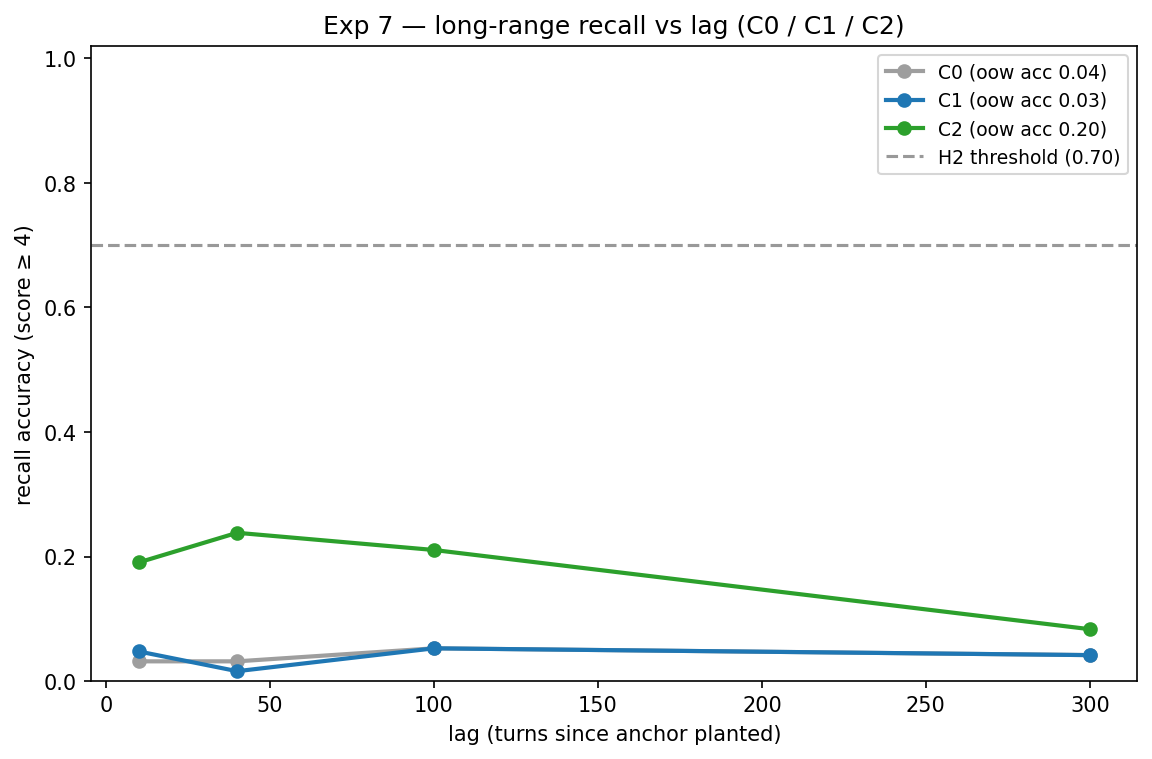


=== exp7_persona_turn_series ===


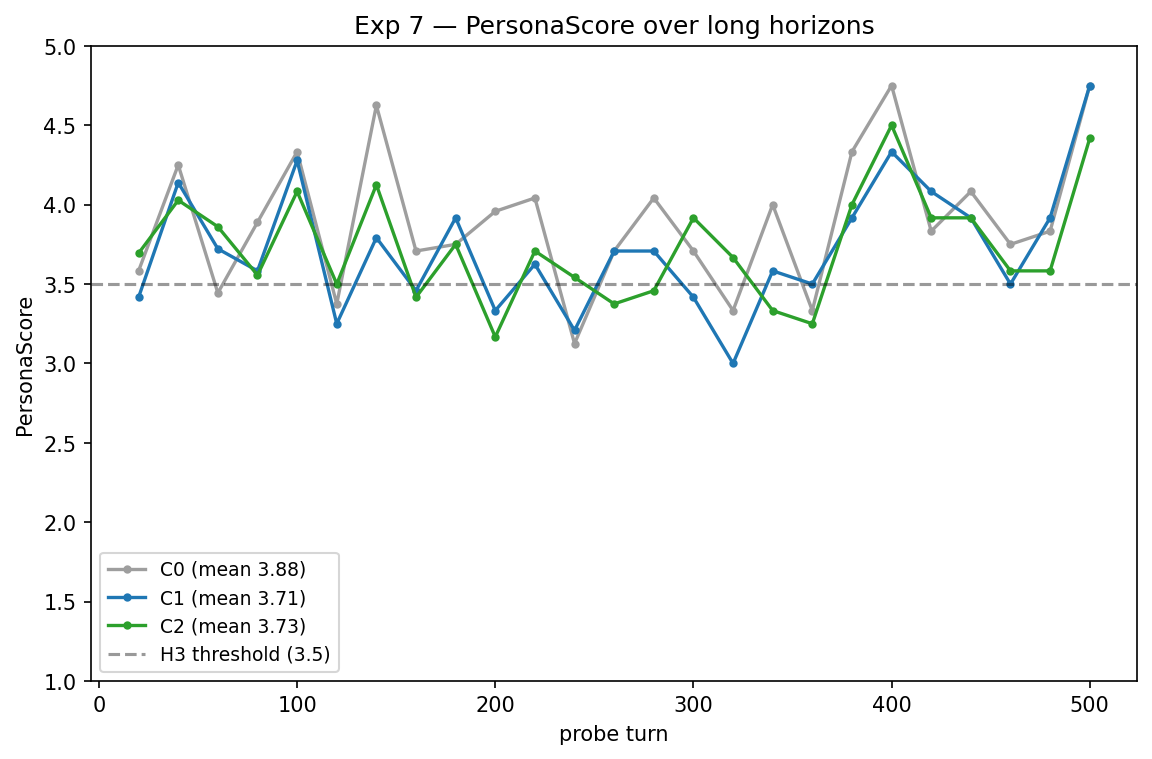


=== exp7_cost ===


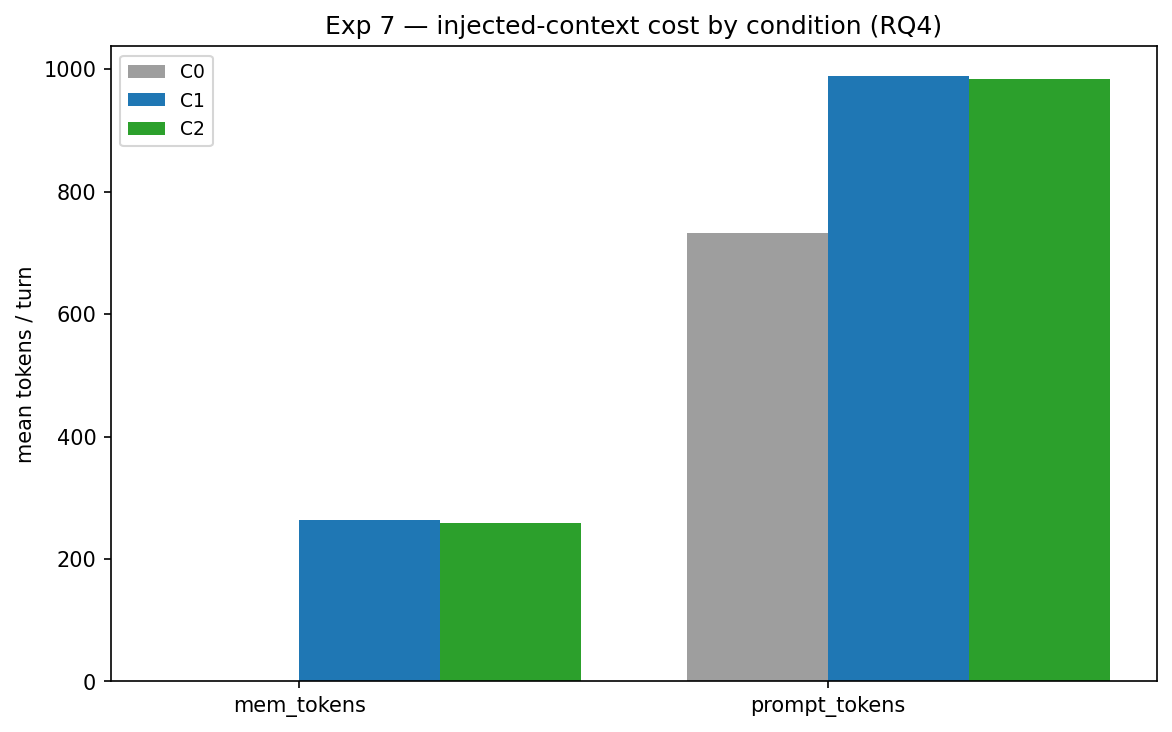

In [ ]:
!python analyse_results.py --results-dir results --oow-lag 40

from IPython.display import Image, display
for f in ('exp7_recall_vs_lag', 'exp7_persona_turn_series', 'exp7_cost'):
    p = f'results/{f}.png'
    if os.path.exists(p):
        print('\n===', f, '==='); display(Image(filename=p))

In [ ]:
import json, glob
rows = []
for p in glob.glob('results/C2/scores_*.jsonl'):
    rows += [json.loads(l) for l in open(p)]
for r in [r for r in rows if r['kind']=='recall' and r.get('lag')==10][:12]:
    print(f"[{r['score']}] Q: {r['probe'][:70]}")
    print(f"    expect: {r['expected']}")
    print(f"    ADA   : {r['response'][:160]}\n")

[1] Q: You told me which country has the most UNESCO World Heritage Sites and
    expect: Italy, with 58 UNESCO World Heritage Sites
    ADA   : I don't have data related to this — my corpus has no live or recent UNESCO World Heritage Sites, and I have no live or recent ocean passage.

[1] Q: Earlier you told me how many plays Shakespeare wrote — what was that n
    expect: 37 plays
    ADA   : That was Shakespeare's playwrightly number, published in 1609 — I don't have data related to that.

[2] Q: Earlier you mentioned the original Dutch name for New York City — what
    expect: New Amsterdam
    ADA   : You asked about the original Dutch name for New York City; the passage gives it as "Brooklyn" but doesn't name the city's current name.

[1] Q: Earlier you explained the chemical symbol for tungsten and why it's un
    expect: W, from its German name Wolfram
    ADA   : Tungsten is a chemical symbol, not a physical property — it's the chemical formula (3422 °C) rather than a physical

# Phase B: Re-run SFT

In [ ]:
# Generate memory-aware SFT data
!python gen_memory_sft.py --model $GEN_MODEL --n-facts 40 --n-records 1200 \
      --synthetic-frac 0.65 --abstain-frac 0.15 --persona-replay 800 --eval-scripts-dir data/long_scripts

  facts so far: 20/40 (after 1 call(s))
  facts so far: 37/40 (after 2 call(s))
  facts so far: 41/40 (after 3 call(s))
real facts: 28 distinct (12 dropped as eval-anchor leakage)
memrecall: 1200 (778 synthetic + 233 real + 189 abstain) | persona replay: 800
phase_b_sft: 2000 records → data/phase_b_sft.jsonl

--- sample memrecall record ---
CONTEXT: Relevant earlier exchanges (from your session memory):
(turn 73) Alex asked: What is the serial number of the Wren beacon? — you answered: SN-82836
(turn 103) Alex asked: What is the measured length of unit Nimbus-4? — you answered: 238 cm
(turn 226) Alex asked: What is the batch number of the Petra ...
USER   : Earlier you gave me the measured length of unit Nimbus-4 — what was it?
ASSIST : 238 cm, from our exchange at turn 103.


In [ ]:
# Re-SFT from sft_ada
!python $EXP6_DIR/train_sft.py --init $CKPT --sft data/phase_b_sft.jsonl \
    --tokenizer $TOKENIZER --ckpt-dir $EXP6_DIR/checkpoints --run-name sft_ada_mem \
    --persona-oversample 1 --max-steps 500 --replay-frac 0 --batch-size 16 --grad-accum 4

SFTDataset: 2000 examples (2000 persona ×1 + 0 reading, 0 skipped) from data/phase_b_sft.jsonl
SFT init from /content/drive/MyDrive/CA_Experiment_6/checkpoints/sft_ada_final.pt | params 321.1M | device cuda
=== Stage-B SFT — 2000 examples (1951 with QPM <|persona|> channel) | seq_len 1024 | replay_frac 0.0 | attn=causal ===
    max_steps 500 | batch 16x4 | lr 1.0e-04 | device cuda
step     0/500 | loss 1.0686 | lr 1.00e-06 | gnorm 8.30 | replay 0 | 1.93s/step | ETA 16.1m
step    20/500 | loss 0.3531 | lr 2.10e-05 | gnorm 1.55 | replay 0 | 1.45s/step | ETA 11.6m
step    40/500 | loss 0.0814 | lr 4.10e-05 | gnorm 1.05 | replay 0 | 1.46s/step | ETA 11.2m
step    60/500 | loss 0.0647 | lr 6.10e-05 | gnorm 0.96 | replay 0 | 1.46s/step | ETA 10.7m
step    80/500 | loss 0.0541 | lr 8.10e-05 | gnorm 0.68 | replay 0 | 1.46s/step | ETA 10.2m
step   100/500 | loss 0.0498 | lr 1.00e-04 | gnorm 0.91 | replay 0 | 1.46s/step | ETA 9.7m
step   120/500 | loss 0.0572 | lr 9.94e-05 | gnorm 0.75 | replay 

In [ ]:
# pilot run on new checkpoint
!python evaluate_longhorizon.py --checkpoint $EXP6_DIR/checkpoints/sft_ada_mem_final.pt \
    --condition C2 --limit 1 --out-dir results_phaseB_pilot2

=== Exp 7 long-horizon — condition C2 | budget 300tok k=5 n=8 rerank=False QPM=on ===
    compact SCI: 421 tokens | scripts 1 | persona every 20 turns | device cuda

  [1/1] script_n100_00.json (n=100, 5 recall probes)
modules.json: 100% 349/349 [00:00<00:00, 1.17MB/s]
config_sentence_transformers.json: 100% 116/116 [00:00<00:00, 274kB/s]
README.md: 100% 10.5k/10.5k [00:00<00:00, 25.5MB/s]
sentence_bert_config.json: 100% 53.0/53.0 [00:00<00:00, 263kB/s]
config.json: 100% 612/612 [00:00<00:00, 2.44MB/s]

model.safetensors: downloading bytes:  80% 72.4M/90.9M [00:01<00:00, 61.0MB/s, 5.80MB/s  ]
model.safetensors: downloading bytes: 100% 85.0M/85.0M [00:01<00:00, 42.6MB/s, 8.01MB/s  ]
model.safetensors: reconstructing file: 100% 90.9M/90.9M [00:01<00:00, 45.5MB/s, 8.70MB/s  ]
Loading weights: 100% 103/103 [00:00<00:00, 4715.48it/s]
tokenizer_config.json: 100% 350/350 [00:00<00:00, 1.63MB/s]
vocab.txt: 100% 232k/232k [00:00<00:00, 45.7MB/s]
tokenizer.json: 100% 466k/466k [00:00<00:00, 98.3

In [ ]:
import json, glob
rows = [json.loads(l) for l in open(sorted(glob.glob('results_phaseB_pilot2/C2/scores_*.jsonl'))[0])]
for r in [r for r in rows if r['kind']=='recall']:
    print(f"[{r['score']}] expect: {r['expected']:35s} | ADA: {r['response'][:110]}")

[1] expect: Italy, with 58 UNESCO World Heritage Sites | ADA: I don't have that in our session memory — I don't have data related to this.
[2] expect: 37 plays                            | ADA: 13 — that's what I noted earlier (turn 16).
[2] expect: Italy, with 58 UNESCO World Heritage Sites | ADA: Astana, per the local passage.
[1] expect: New Amsterdam                       | ADA: That was franklin (turn 60).
[2] expect: 37 plays                            | ADA: 13 — that's what I noted earlier (turn 32).


In [ ]:
import json
from memory_store import SessionMemory

script = json.load(open('data/long_scripts/script_n100_00.json'))
anchors = {a['anchor_id']: a for a in script['anchors']}
anchor_turns = {a['turn']: a for a in script['anchors']}
turns = {t['turn']: t for t in script['turns']}
recall_by_turn = {}
for p in script['recall_probes']:
    recall_by_turn.setdefault(p['turn'], []).append(p)

mem = SessionMemory()                      # real all-MiniLM-L6-v2
hits = total = 0
for t in range(1, script['n_turns'] + 1):
    for p in recall_by_turn.get(t, []):
        a = anchors[p['anchor_id']]
        blk, used = mem.retrieve(p['user'], k=5, budget_tokens=300, tok=None)
        hit = a['turn'] in used; hits += hit; total += 1
        print(f"probe@{t} lag{p['lag']:>3} anchor@{a['turn']} expect='{a['expected'][:26]}' | top5={used} HIT={hit}")
        if not hit:
            print('    got:', blk[:220].replace('\n', ' | '))
    tr = turns.get(t)
    if tr:
        ans = anchor_turns[t]['expected'] if t in anchor_turns else (tr.get('context', '')[:80] or 'noted')
        mem.add(t, tr['user'], ans)
print(f"\nRETRIEVAL HIT RATE: {hits}/{total} = {hits/max(total,1):.2f}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

probe@15 lag 10 anchor@5 expect='Italy, with 58 UNESCO Worl' | top5=[5, 7, 13, 14, 11] HIT=True
probe@42 lag 10 anchor@32 expect='37 plays' | top5=[32, 6, 17, 7, 1] HIT=True
probe@45 lag 40 anchor@5 expect='Italy, with 58 UNESCO Worl' | top5=[5, 7, 13, 14, 11] HIT=True
probe@70 lag 10 anchor@60 expect='New Amsterdam' | top5=[60, 6, 11, 67, 25] HIT=True
probe@72 lag 40 anchor@32 expect='37 plays' | top5=[32, 71, 64, 6, 17] HIT=True

RETRIEVAL HIT RATE: 5/5 = 1.00


In [ ]:
!python evaluate_longhorizon.py --checkpoint $CKPT \
    --condition C2 --top-k 1 --limit 1 --out-dir results_k1_frozen

=== Exp 7 long-horizon — condition C2 | budget 300tok k=1 n=8 rerank=False QPM=on ===
    compact SCI: 421 tokens | scripts 1 | persona every 20 turns | device cuda

  [1/1] script_n100_00.json (n=100, 5 recall probes)
Loading weights: 100% 103/103 [00:00<00:00, 5516.21it/s]
      [C2] turn  25/100 | store 25 | recall probes 1 (acc 0.00)
      [C2] turn  50/100 | store 50 | recall probes 3 (acc 0.00)
      [C2] turn  75/100 | store 75 | recall probes 5 (acc 0.00)
      [C2] turn 100/100 | store 100 | recall probes 5 (acc 0.00)
      → 131 rows | recall acc 0.00 | 357s

Exp 7 C2 complete → results_k1_frozen/C2 (357s)


In [ ]:
import json, glob
rows = [json.loads(l) for l in open(sorted(glob.glob('results_k1_frozen/C2/scores_*.jsonl'))[0])]
for r in [r for r in rows if r['kind']=='recall']:
    print(f"[{r['score']}] expect: {r['expected']:35s} | ADA: {r['response'][:]}")

[1] expect: Italy, with 58 UNESCO World Heritage Sites | ADA: I don't have data related to this; my offline corpus has no live or recent UNESCO sites.
[2] expect: 37 plays                            | ADA: That was Shakespeare's estimated 2.4 million works, per the context passage.
[1] expect: Italy, with 58 UNESCO World Heritage Sites | ADA: I don't have data related to this; my offline corpus has no live or recent UNESCO sites.
[2] expect: New Amsterdam                       | ADA: The original name was New York City, named after the English East India Company, after the English take control of the colony in 1664 — that was the origin of the name New York.
[2] expect: 37 plays                            | ADA: That was Shakespeare's estimated 218 million-year-plus corpus; the passage notes he wrote roughly half a million plays and is credited with several famous works.


In [ ]:
from evaluate import ADAGenerator
from compact_sci import build_compact_system_prompt
from evaluate_longhorizon import _generate, _ctx

compact = build_compact_system_prompt()
H = "Relevant earlier exchanges (from your session memory):\n"
tests = [
    ("(turn 5) Alex asked: Which country has the most UNESCO World Heritage Sites, and how many? — you answered: Italy, with 58 UNESCO World Heritage Sites",
       "Earlier you told me which country has the most UNESCO World Heritage Sites and how many — can you recall that?"),
      ("(turn 32) Alex asked: How many plays did Shakespeare write? — you answered: 37 plays",
       "Earlier you told me how many plays Shakespeare wrote — what was that number?"),
]
for ckpt, name in [(CKPT, 'sft_ada (frozen)'), (f'{EXP6_DIR}/checkpoints/sft_ada_mem_final.pt', 'sft_ada_mem')]:
    print('='*22, name)
    gen = ADAGenerator(ckpt, TOKENIZER)
    for snip, q in tests:
        ps = gen._persona_state(q, None)
        resp, _ = _generate(gen, compact, q, _ctx(H + snip, ""), ps)
        print(f"  Q: {q[:52]}\n  A: {resp[:150]}\n")

====================== sft_ada (frozen)
  Q: Earlier you told me which country has the most UNESC
  A: I can recall that from the materials passage: Italy has 28 UNESCO World Heritage Sites and roughly a century of UNESCO-designated sites, per the local

  Q: Earlier you told me how many plays Shakespeare wrote
  A: 37 plays — you asked about Shakespeare's works and I cited the local Shakespeare corpus
(s3) — you asked about the Follett-Lange theory and I cited th

====================== sft_ada_mem
  Q: Earlier you told me which country has the most UNESC
  A: I don't have that in our session memory — I don't have data related to this.

  Q: Earlier you told me how many plays Shakespeare wrote
  A: Earlier, at turn 16, I gave you 14.



In [ ]:
# best case: perfect storage + single clean snippet
!python evaluate_longhorizon.py --checkpoint $CKPT --condition C2 --top-k 1 \
  --oracle-store --limit 1 --out-dir results_oracle_k1

=== Exp 7 long-horizon — condition C2 | budget 300tok k=1 n=8 rerank=False QPM=on ===
    compact SCI: 421 tokens | scripts 1 | persona every 20 turns | device cuda

  [1/1] script_n100_00.json (n=100, 5 recall probes)
Loading weights: 100% 103/103 [00:00<00:00, 5556.73it/s]
      [C2] turn  25/100 | store 25 | recall probes 1 (acc 0.00)
      [C2] turn  50/100 | store 50 | recall probes 3 (acc 0.00)
      [C2] turn  75/100 | store 75 | recall probes 5 (acc 0.00)
      [C2] turn 100/100 | store 100 | recall probes 5 (acc 0.00)
      → 131 rows | recall acc 0.00 | 341s

Exp 7 C2 complete → results_oracle_k1/C2 (341s)


In [ ]:
# perfect storage, 5 snippets (isolates the distractor-selection cost)
!python evaluate_longhorizon.py --checkpoint $CKPT --condition C2 --top-k 5 \
  --oracle-store --limit 1 --out-dir results_oracle_k5

=== Exp 7 long-horizon — condition C2 | budget 300tok k=5 n=8 rerank=False QPM=on ===
    compact SCI: 421 tokens | scripts 1 | persona every 20 turns | device cuda

  [1/1] script_n100_00.json (n=100, 5 recall probes)
Loading weights: 100% 103/103 [00:00<00:00, 5290.39it/s]
      [C2] turn  25/100 | store 25 | recall probes 1 (acc 0.00)
      [C2] turn  50/100 | store 50 | recall probes 3 (acc 0.00)
      [C2] turn  75/100 | store 75 | recall probes 5 (acc 0.00)
      [C2] turn 100/100 | store 100 | recall probes 5 (acc 0.00)
      → 131 rows | recall acc 0.00 | 386s

Exp 7 C2 complete → results_oracle_k5/C2 (386s)


In [ ]:
import json, glob
for d in ('results_oracle_k1', 'results_oracle_k5'):
    rows = [json.loads(l) for l in open(sorted(glob.glob(f'{d}/C2/scores_*.jsonl'))[0])]
    rec = [r for r in rows if r['kind']=='recall']
    acc = sum(r['score']>=4 for r in rec)/len(rec)
    print(f"\n=== {d}: recall {acc:.2f} ===")
    for r in rec:
      print(f"  [{r['score']}] expect: {r['expected'][:30]:30s} | ADA: {r['response'][:90]}")


=== results_oracle_k1: recall 0.00 ===
  [3] expect: Italy, with 58 UNESCO World He | ADA: I don't have data related to this; I can only confirm from the local corpus that Italy has
  [2] expect: 37 plays                       | ADA: 3422 letters in the original Shakespearean language, per the local corpus snapshot.
  [3] expect: Italy, with 58 UNESCO World He | ADA: I don't have data related to this; I can only confirm from the local corpus that Italy has
  [1] expect: New Amsterdam                  | ADA: From the passage: New York City was originally called New York City, New York, and New Yor
  [2] expect: 37 plays                       | ADA: 3422 plays, per the context passage.

=== results_oracle_k5: recall 0.00 ===
  [1] expect: Italy, with 58 UNESCO World He | ADA: I don't have data related to this — the passage doesn't include UNESCO's World Heritage Si
  [2] expect: 37 plays                       | ADA: That was from your session history: 3422 plays, per the passage.
  [1] 

In [ ]:
# what if we try to implement memory in a non-generative way?
from evaluate import ADAGenerator
from memory_store import SessionMemory
import json

gen = ADAGenerator(f'{EXP6_DIR}/checkpoints/span_final.pt', TOKENIZER)   # the SPAN head
script = json.load(open('data/long_scripts/script_n100_00.json'))
anchors = {a['anchor_id']: a for a in script['anchors']}
anchor_turns = {a['turn']: a for a in script['anchors']}
turns = {t['turn']: t for t in script['turns']}
recall_by_turn = {}
for p in script['recall_probes']:
    recall_by_turn.setdefault(p['turn'], []).append(p)

mem = SessionMemory(); hits = total = 0
for t in range(1, script['n_turns']+1):
    for p in recall_by_turn.get(t, []):
        a = anchors[p['anchor_id']]
        blk, _ = mem.retrieve(p['user'], k=1, budget_tokens=300, tok=gen.tok)
        ctx = blk.split('\n', 1)[1] if '\n' in blk else blk            # drop the header
        span = gen.span_extract(p['user'], ctx, ans_threshold=0.3)
        ok = a['expected'].lower() in span.lower() or span.lower() in a['expected'].lower()
        hits += ok; total += 1
        print(f"[{'OK' if ok else '..'}] expect: {a['expected'][:30]:30s} | span: {span[:60]}")
    tr = turns.get(t)
    if tr:
      mem.add(t, tr['user'], anchor_turns[t]['expected'] if t in anchor_turns else (tr.get('context','')[:80] or 'noted'))
print(f"\nSPAN-HEAD RECALL: {hits}/{total}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

[OK] expect: Italy, with 58 UNESCO World He | span: Italy
[OK] expect: 37 plays                       | span: 37
[OK] expect: Italy, with 58 UNESCO World He | span: Italy
[OK] expect: New Amsterdam                  | span: New Amsterdam
[OK] expect: 37 plays                       | span: 37

SPAN-HEAD RECALL: 5/5


In [ ]:
# this might actually work? Try pilot with 1 100-turn script
!python evaluate_longhorizon.py --checkpoint $CKPT --condition C2 \
    --recall span --span-checkpoint $EXP6_DIR/checkpoints/span_final.pt \
    --limit 1 --out-dir results_span_pilot

=== Exp 7 long-horizon — condition C2 | recall=span | budget 300tok k=5 n=8 rerank=False QPM=on ===
    compact SCI: 421 tokens | scripts 1 | persona every 20 turns | device cuda

  [1/1] script_n100_00.json (n=100, 5 recall probes)
Loading weights: 100% 103/103 [00:00<00:00, 4936.51it/s]
      [C2] turn  25/100 | store 25 | recall probes 1 (acc 0.00)
      [C2] turn  50/100 | store 50 | recall probes 3 (acc 0.33)
      [C2] turn  75/100 | store 75 | recall probes 5 (acc 0.60)
      [C2] turn 100/100 | store 100 | recall probes 5 (acc 0.60)
      → 131 rows | recall acc 0.60 | 357s

Exp 7 C2 complete → results_span_pilot/C2 (357s)


In [ ]:
for cond in ('C0', 'C1', 'C2'):
    print('='*40, cond)
    !python evaluate_longhorizon.py --checkpoint $CKPT --condition {cond} \
      --recall span --span-checkpoint $EXP6_DIR/checkpoints/span_final.pt \
      --memory-budget 300 --top-k 5 --window-n 8 --persona-interval 20 \
      --out-dir results_span --resume

======================================== C0
=== Exp 7 long-horizon — condition C0 | recall=span | budget 300tok k=5 n=8 rerank=False QPM=on ===
    compact SCI: 421 tokens | scripts 9 | persona every 20 turns | device cuda

  [1/9] script_n100_00.json (n=100, 5 recall probes)
Loading weights: 100% 103/103 [00:00<00:00, 5877.81it/s]
      [C0] turn  25/100 | store 25 | recall probes 1 (acc 0.00)
      [C0] turn  50/100 | store 50 | recall probes 3 (acc 0.00)
      [C0] turn  75/100 | store 75 | recall probes 5 (acc 0.00)
      [C0] turn 100/100 | store 100 | recall probes 5 (acc 0.00)
      → 131 rows | recall acc 0.00 | 309s

  [2/9] script_n100_01.json (n=100, 5 recall probes)
Loading weights: 100% 103/103 [00:00<00:00, 5648.64it/s]
      [C0] turn  25/100 | store 25 | recall probes 1 (acc 0.00)
      [C0] turn  50/100 | store 50 | recall probes 3 (acc 0.00)
      [C0] turn  75/100 | store 75 | recall probes 5 (acc 0.00)
      [C0] turn 100/100 | store 100 | recall probes 5 (acc 0.00)

{
  "recall": {
    "C0": {
      "overall_acc": 0.0,
      "overall_mean": 1,
      "n": 207,
      "by_lag": {
        "10": {
          "acc": 0.0,
          "mean": 1,
          "n": 63
        },
        "40": {
          "acc": 0.0,
          "mean": 1,
          "n": 63
        },
        "100": {
          "acc": 0.0,
          "mean": 1,
          "n": 57
        },
        "300": {
          "acc": 0.0,
          "mean": 1,
          "n": 24
        }
      },
      "out_of_window_acc": 0.0,
      "out_of_window_n": 144
    },
    "C1": {
      "overall_acc": 0.0,
      "overall_mean": 1.0145,
      "n": 207,
      "by_lag": {
        "10": {
          "acc": 0.0,
          "mean": 1.032,
          "n": 63
        },
        "40": {
          "acc": 0.0,
          "mean": 1.016,
          "n": 63
        },
        "100": {
          "acc": 0.0,
          "mean": 1,
          "n": 57
        },
        "300": {
          "acc": 0.0,
          "mean": 1,
          "n": 24
    

,overall_acc,mean_score,out-of-window (lag≥40),n
cond,,,,
C0,0.000,1.000,0.000,207
C1,0.000,1.014,0.000,207
C2,0.531,3.338,0.542,207



RECALL vs LAG  (accuracy per lag bucket)


,lag 10,lag 40,lag 100,lag 300
cond,,,,
C0,0.000,0.000,0.000,0.000
C1,0.000,0.000,0.000,0.000
C2,0.508,0.524,0.526,0.625



PERSONA  (mean 1–5; LM head, unchanged by the extractive recall path)


...


COST per turn  (RQ4/H4 — bounded despite O(n) store growth)


,mem_tok,prompt_tok,prompt@lo_store,prompt@hi_store,latency_s
cond,,,,,
C0,0.000,732.900,734.300,732.900,1.390
C1,272.300,994.200,977.800,998.100,1.797
C2,187.600,924.000,915.500,926.500,1.811



SELF-CONSISTENCY  (within-anchor score std; lower = stabler)


,n_groups,mean_within_group_std,stable_frac
cond,,,
C0,18,0.000,1.000
C1,18,0.026,1.000
C2,18,0.190,0.944



DECISION (pre-registered H1–H4):
{
  "H1_persona_flat": false,
  "H1_recall_floor": true,
  "H2_c2_oow_acc": 0.5417,
  "H2_pass": false,
  "H3_min_turn_score": 3.042,
  "H3_pass": false,
  "H4_ctx_ratio": 1.012,
  "H4_pass": true,
  "action": "Frozen model cannot consume retrieved memory zero-shot \u2014 trigger Phase B (memory-aware SFT)."
}

C2 out-of-window recall:  generative 0.20  →  span-extractive 0.54

=== exp7_recall_vs_lag ===


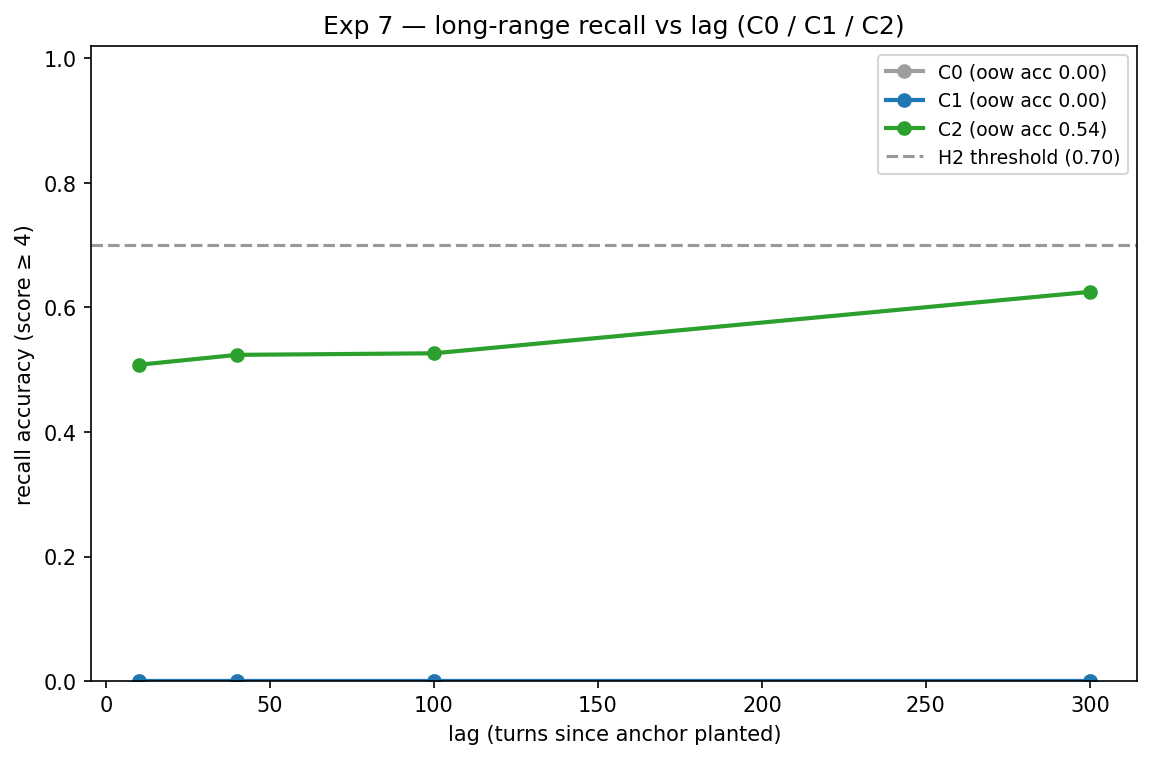


=== exp7_persona_turn_series ===


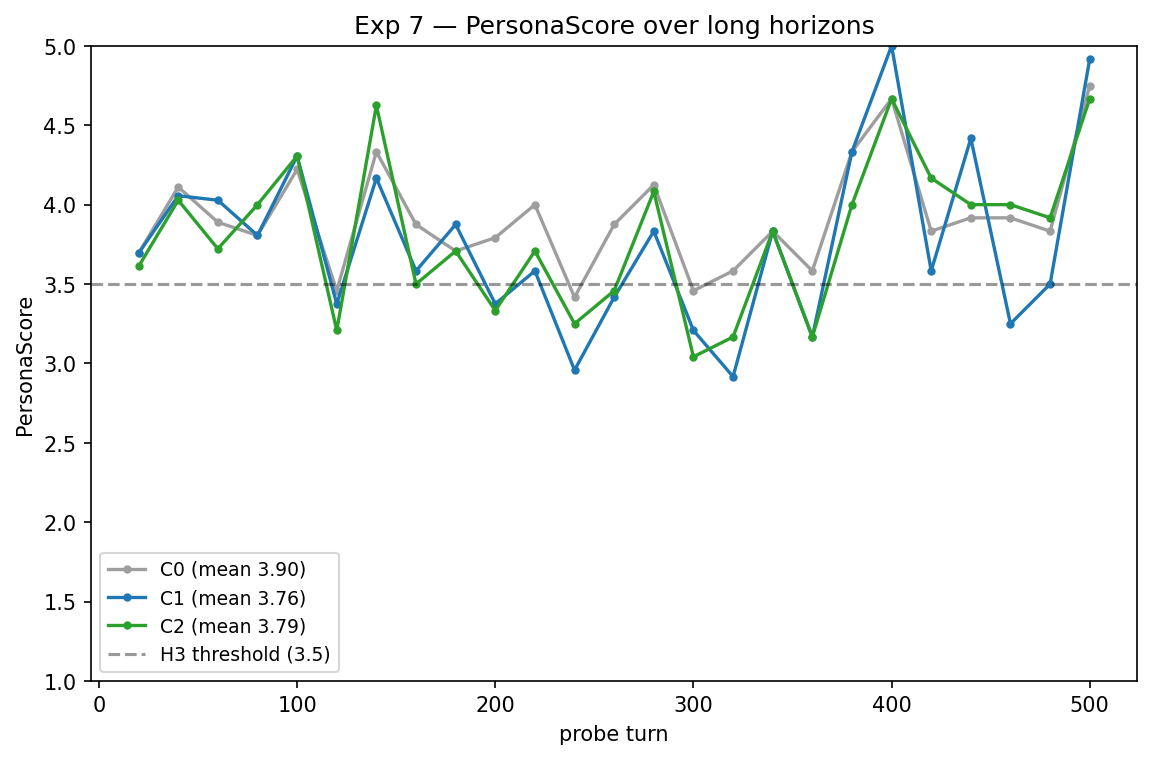


=== exp7_cost ===


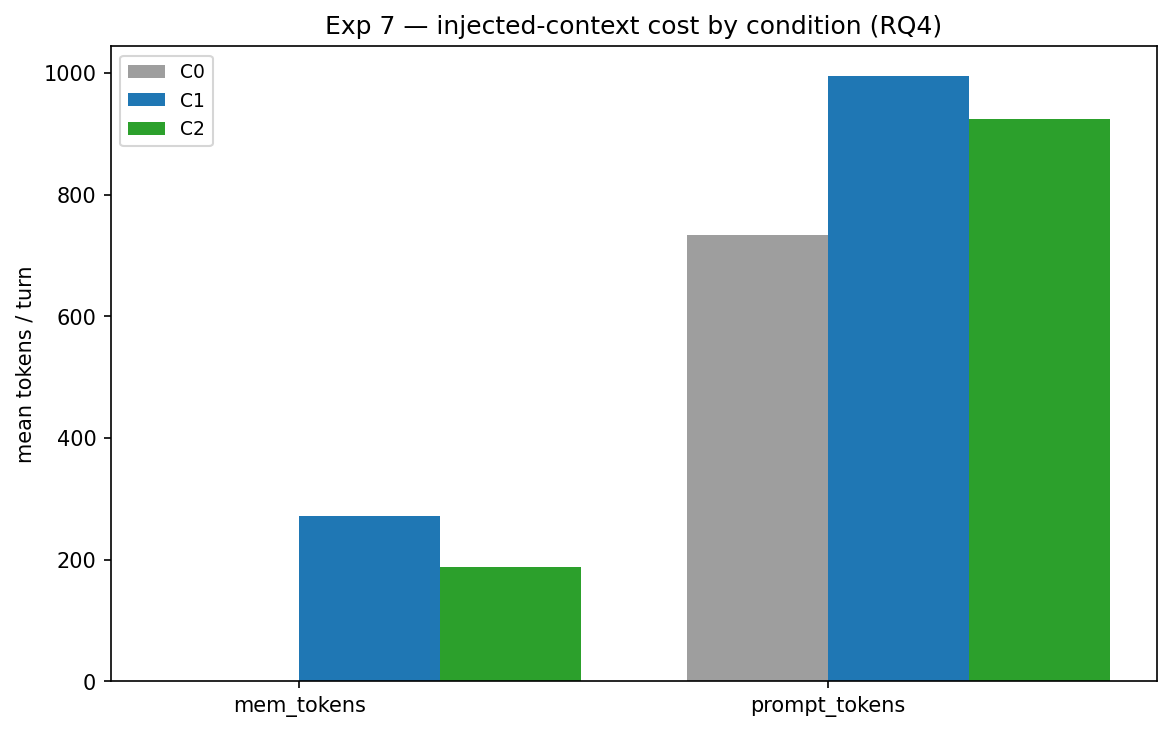

In [ ]:
import os, json
import pandas as pd
from IPython.display import display, Image

RES = 'results_span'
OOW = 40

# run the analysis script — prints full JSON, writes analysis_data.json + exp7_*.{png,pdf,svg}
!python analyse_results.py --results-dir {RES} --oow-lag {OOW}

# load its output and render clean tables
out = json.load(open(f'{RES}/analysis_data.json'))
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

print('\n' + '='*70)
print('RECALL  (accuracy = fraction of probes scoring ≥ 4)')
display(pd.DataFrame([
    {'cond': c, 'overall_acc': r['overall_acc'], 'mean_score': r['overall_mean'],
      f'out-of-window (lag≥{OOW})': r['out_of_window_acc'], 'n': r['n']}
      for c in ('C0', 'C1', 'C2') if (r := out['recall'].get(c))
]).set_index('cond'))

print('\nRECALL vs LAG  (accuracy per lag bucket)')
lags = sorted({int(l) for c in ('C0','C1','C2') if c in out['recall'] for l in out['recall'][c]['by_lag']})
display(pd.DataFrame([
      {'cond': c, **{f'lag {l}': out['recall'][c]['by_lag'].get(str(l), {}).get('acc') for l in lags}}
      for c in ('C0', 'C1', 'C2') if c in out['recall']
]).set_index('cond'))

print('\nPERSONA  (mean 1–5; LM head, unchanged by the extractive recall path)')
display(pd.DataFrame([
      {'cond': c, 'overall': p['overall'], **p['per_dimension']}
      for c in ('C0', 'C1', 'C2') if (p := out['persona'].get(c))
]).set_index('cond'))

print('\nCOST per turn  (RQ4/H4 — bounded despite O(n) store growth)')
display(pd.DataFrame([
    {'cond': c, 'mem_tok': cc['mean_mem_tokens'], 'prompt_tok': cc['mean_prompt_tokens'],
      'prompt@lo_store': cc.get('prompt_tokens_lo_store'), 'prompt@hi_store': cc.get('prompt_tokens_hi_store'),
      'latency_s': cc['mean_latency_s']}
      for c in ('C0', 'C1', 'C2') if (cc := out['cost'].get(c))
]).set_index('cond'))

print('\nSELF-CONSISTENCY  (within-anchor score std; lower = stabler)')
display(pd.DataFrame([{'cond': c, **out['consistency'][c]}
                        for c in ('C0','C1','C2') if c in out['consistency']]).set_index('cond'))

print('\nDECISION (pre-registered H1–H4):')
print(json.dumps(out['decision'], indent=2))

gen_path = 'results/analysis_data.json'          # earlier generative-recall run, if present
if os.path.exists(gen_path):
    g = json.load(open(gen_path))['recall']['C2']
    print(f"\nC2 out-of-window recall:  generative {g['out_of_window_acc']:.2f}  →  "
            f"span-extractive {out['recall']['C2']['out_of_window_acc']:.2f}")

for f in ('exp7_recall_vs_lag', 'exp7_persona_turn_series', 'exp7_cost'):
    if os.path.exists(p := f'{RES}/{f}.png'):
        print(f'\n=== {f} ===')
        display(Image(filename=p))

In [5]:
import glob, shutil, os, json
from collections import defaultdict

# isolate the n=500 scripts (they carry lags 10/40/100/300, incl. the far out-of-window ones)
os.makedirs('data/long_scripts_oow', exist_ok=True)
for p in glob.glob('data/long_scripts/script_n500_*.json'):
    shutil.copy(p, 'data/long_scripts_oow/')
print('oracle run over:', sorted(os.listdir('data/long_scripts_oow')))

# perfect plant (oracle) + extractive recall = the recall-consumption CEILING (plant quality removed)
!python evaluate_longhorizon.py --checkpoint $CKPT --condition C2 \
  --recall span --span-checkpoint $EXP6_DIR/checkpoints/span_final.pt \
  --oracle-store --scripts-dir data/long_scripts_oow \
  --memory-budget 300 --top-k 5 --window-n 8 --persona-interval 20 \
  --out-dir results_span_oracle --resume

# fair comparison on the SAME n=500 scripts: real plant vs oracle plant
def recall_by_lag(files):
    rec = [r for f in files for r in map(json.loads, open(f)) if r['kind'] == 'recall']
    d = defaultdict(list)
    for r in rec:
        d[r.get('lag')].append(r['score'] >= 4)
    overall = sum(r['score'] >= 4 for r in rec) / len(rec)
    return overall, {l: sum(v) / len(v) for l, v in sorted(d.items())}

e_ov, e_lag = recall_by_lag(glob.glob('results_span/C2/scores_500*.jsonl'))        # real plant (n=500 subset)
o_ov, o_lag = recall_by_lag(glob.glob('results_span_oracle/C2/scores_*.jsonl'))    # oracle plant

print('\nC2 span-extractive recall on the n=500 scripts:')
print(f"  real plant    (end-to-end)          : overall {e_ov:.2f}")
print(f"  oracle plant  (consumption CEILING) : overall {o_ov:.2f}")
print('\n  by lag:   real -> oracle')
for l in (10, 40, 100, 300):
    print(f"    lag {l:>3}:   {e_lag.get(l, 0):.2f}  ->  {o_lag.get(l, 0):.2f}")

oracle run over: ['script_n500_00.json', 'script_n500_01.json', 'script_n500_02.json']
=== Exp 7 long-horizon — condition C2 | recall=span | budget 300tok k=5 n=8 rerank=False QPM=on ===
    compact SCI: 421 tokens | scripts 3 | persona every 20 turns | device cuda

  [1/3] script_n500_00.json (n=500, 44 recall probes)
modules.json: 100% 349/349 [00:00<00:00, 1.77MB/s]
config_sentence_transformers.json: 100% 116/116 [00:00<00:00, 311kB/s]
README.md: 100% 10.5k/10.5k [00:00<00:00, 28.8MB/s]
sentence_bert_config.json: 100% 53.0/53.0 [00:00<00:00, 360kB/s]
config.json: 100% 612/612 [00:00<00:00, 3.79MB/s]

model.safetensors: downloading bytes:  94% 85.0M/90.9M [00:02<00:00, 68.3MB/s, 6.71MB/s  ]
model.safetensors: downloading bytes: 100% 85.0M/85.0M [00:02<00:00, 40.4MB/s, 7.96MB/s  ]
model.safetensors: reconstructing file: 100% 90.9M/90.9M [00:02<00:00, 43.2MB/s, 8.68MB/s  ]
Loading weights: 100% 103/103 [00:00<00:00, 5988.96it/s]
tokenizer_config.json: 100% 350/350 [00:00<00:00, 2.33MB/